# Weibull Distribution

## 1. Purpose

This notebook analyzes the Weibull distribution in the context of reliability engineering. The objective is to compute reliability metrics such as PDF, CDF, hazard rate, and MTTF, and apply them to engineering problems.

## 2. Mathematical Model

The Weibull probability density function is:

$$
f(x) = \frac{\beta}{\alpha} \left(\frac{x}{\alpha}\right)^{\beta - 1} e^{-(x/\alpha)^\beta}
$$

The cumulative distribution function is:

$$
F(x) = 1 - e^{-(x/\alpha)^\beta}
$$

The mean time to failure (MTTF) is:

$$
\text{MTTF} = \alpha \, \Gamma\left(1 + \frac{1}{\beta}\right)
$$

The Reliability function is:

$$
R(x) = e^{-(x/\alpha)^\beta}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
from scipy.stats import weibull_min

In [ ]:
def weibull_pdf(x, beta, alpha):
    return (beta/alpha) * (x/alpha)**(beta - 1) * np.exp(-(x/alpha)**beta)

def weibull_cdf(x, beta, alpha):
    return 1 - np.exp(-(x/alpha)**beta)

def weibull_mttf(beta, alpha):
    return alpha * gamma(1 + 1/beta)

def weibull_hazard(x, beta, alpha):
    return weibull_pdf(x, beta, alpha) / (1 - weibull_cdf(x, beta, alpha))

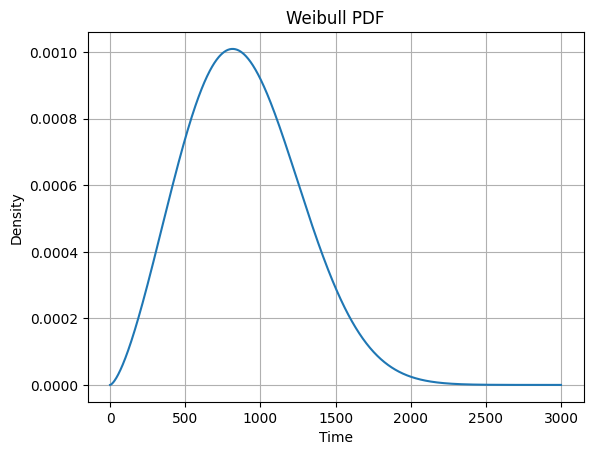

In [3]:
# Visualization

x = np.linspace(0, 3000, 1000)
beta = 2.5
eta = 1000

pdf = weibull_pdf(x, beta, eta)

plt.plot(x, pdf)
plt.title("Weibull PDF")
plt.xlabel("Time")
plt.ylabel("Density")
plt.grid()
plt.show()

# Exercises

## Exercise 3.2
Time to failure of a relay follows a Weibull distribution with $\alpha = 10$ years, $\beta=0.5$. Find the following:

a. Pr(failure after 1 year)
b. Pr(failure after 10 years)
c. MTTF

### Solution

Weibull cdf returns the failure rate until moment $x$. If we sought for failure _after_ that moment, then we need to calculate the complementary probability, i.e.:

$$
P(T > t) = 1 - F(x) = 1 - 1 + e^{-(x/\alpha)^\beta} = e^{-(x/\alpha)^\beta}
$$

In [ ]:
# Inputs
alpha = 10
beta = 0.5
year_a = 1
year_b = 10

# A failure after 1 year
pr_1year = 1 - weibull_cdf(year_a, beta, alpha)

# A failure after 10 years
pr_10years = 1 - weibull_cdf(year_b, beta, alpha)

# MTTF expected
mttf = weibull_mttf(beta, alpha)

print("Probability of failure after 1 year:", pr_1year)
print("Probability of failure after 10 years:", pr_10years)
print("MTTF:", mttf)

Probability of failure after 1 year: 0.7288934141100246
Probability of failure after 10 years: 0.36787944117144233
MTTF: 20.0
